# Experiment 6: Analyzing and Interpreting Statistical Distributions

**Dataset:** `irrigation_prediction.csv` (irrigation and environmental measurements)  
**Aim:** Analyze selected quantitative measurements with numerical summaries, plots, outlier checks, and theoretical distribution comparisons.

The source handout refers to robotic sensor measurements. Here, the supplied irrigation dataset is used, so the selected fields represent environmental or soil measurements. Activity 6 includes **skewness only**, as requested.


## Activity 1 — Load the dataset

Run the notebook from the folder containing `irrigation_prediction.csv`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

csv_path = Path('irrigation_prediction.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Dataset not found: {csv_path.resolve()}')
df = pd.read_csv(csv_path)
print(f'Dataset: {csv_path.name}')
print(f'Rows: {len(df):,}; columns: {df.shape[1]}')
print('Column names:', ', '.join(df.columns))
print('Missing values by column:')
print(df.isna().sum().to_string())


Dataset: irrigation_prediction.csv
Rows: 10,000; columns: 20
Column names: Soil_Type, Soil_pH, Soil_Moisture, Organic_Carbon, Electrical_Conductivity, Temperature_C, Humidity, Rainfall_mm, Sunlight_Hours, Wind_Speed_kmh, Crop_Type, Crop_Growth_Stage, Season, Irrigation_Type, Water_Source, Field_Area_hectare, Mulching_Used, Previous_Irrigation_mm, Region, Irrigation_Need
Missing values by column:
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0


## Activity 2 — Select suitable measurement attributes

Soil moisture, temperature, humidity, rainfall, and electrical conductivity are continuous soil or environmental measurements relevant to irrigation. The categorical `Irrigation_Need` label is not treated as a sensor reading.


In [2]:
selected = {
    'Soil_Moisture': 'Soil moisture',
    'Temperature_C': 'Temperature (°C)',
    'Humidity': 'Humidity',
    'Rainfall_mm': 'Rainfall (mm)',
    'Electrical_Conductivity': 'Electrical conductivity',
}
measurements = df[list(selected)].apply(pd.to_numeric, errors='coerce')
print('Selected measurements and valid counts:')
print(measurements.count().rename('Valid readings').to_string())


Selected measurements and valid counts:
Soil_Moisture              10000
Temperature_C              10000
Humidity                   10000
Rainfall_mm                10000
Electrical_Conductivity    10000


## Activity 3 — Calculate mean, median, and standard deviation


In [3]:
summary = pd.DataFrame({
    'Count': measurements.count(),
    'Mean': measurements.mean(),
    'Median': measurements.median(),
    'Std_dev_sample': measurements.std(ddof=1),
}).round(3)
print(summary.to_string())


                         Count      Mean    Median  Std_dev_sample
Soil_Moisture            10000    36.969    37.240          16.431
Temperature_C            10000    26.991    27.090           8.664
Humidity                 10000    60.080    60.040          20.188
Rainfall_mm              10000  1252.499  1250.335         715.582
Electrical_Conductivity  10000     1.792     1.780           0.984


## Activity 4 — Plot histograms


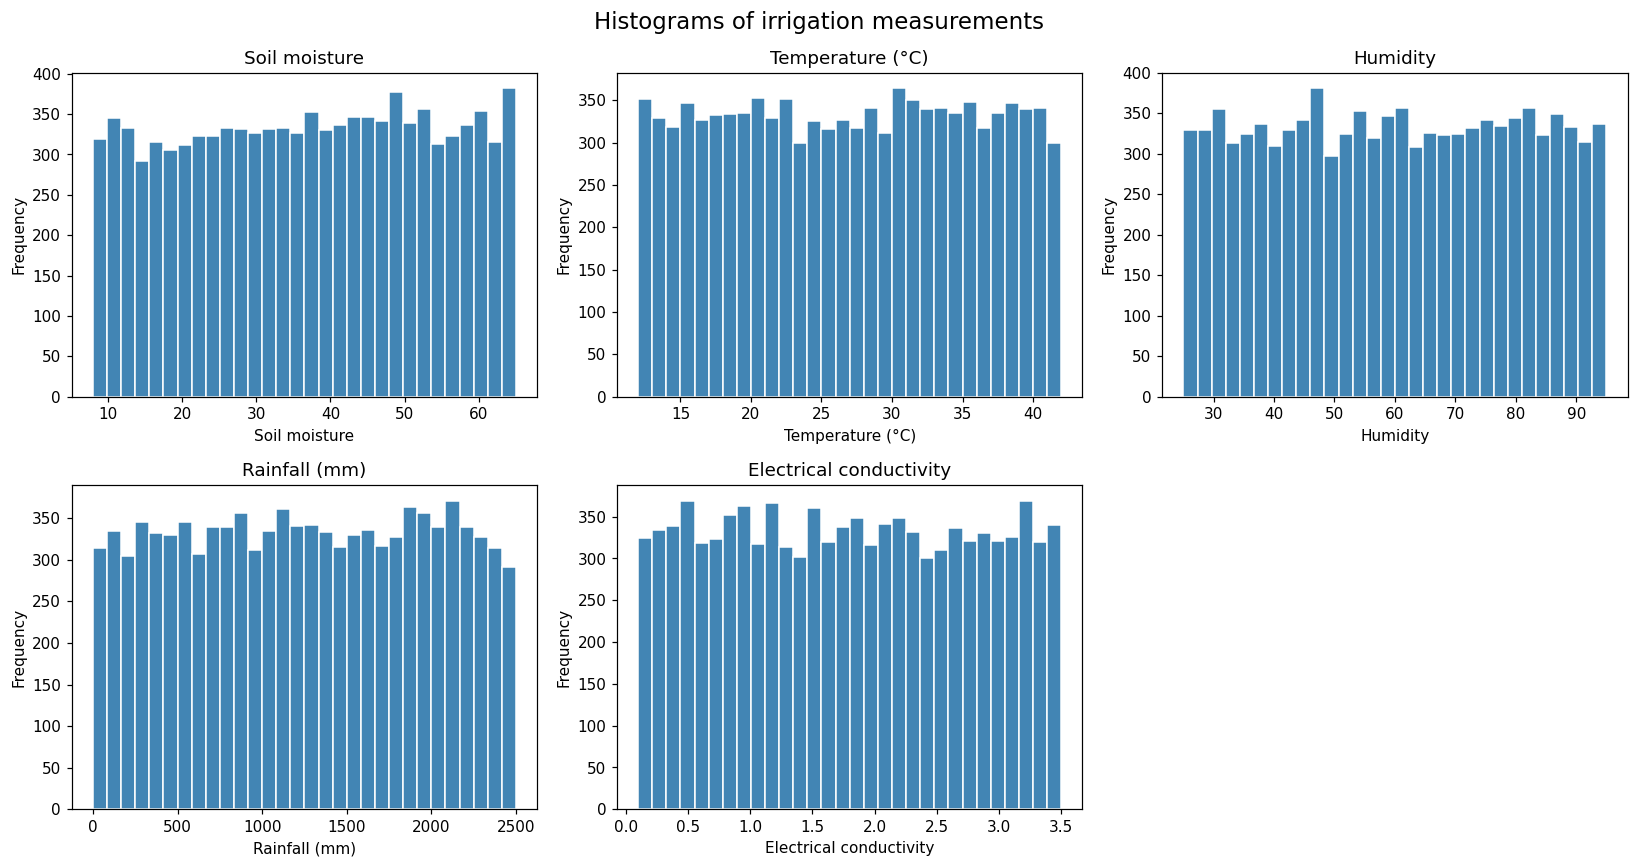

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (column, label) in zip(axes.flat, selected.items()):
    ax.hist(measurements[column].dropna(), bins=30, color='#4285b4', edgecolor='white')
    ax.set(title=label, xlabel=label, ylabel='Frequency')
for ax in list(axes.flat)[len(selected):]:
    ax.axis('off')
fig.suptitle('Histograms of irrigation measurements', fontsize=15)
fig.tight_layout()
plt.show()


## Activity 5 — Generate density plots


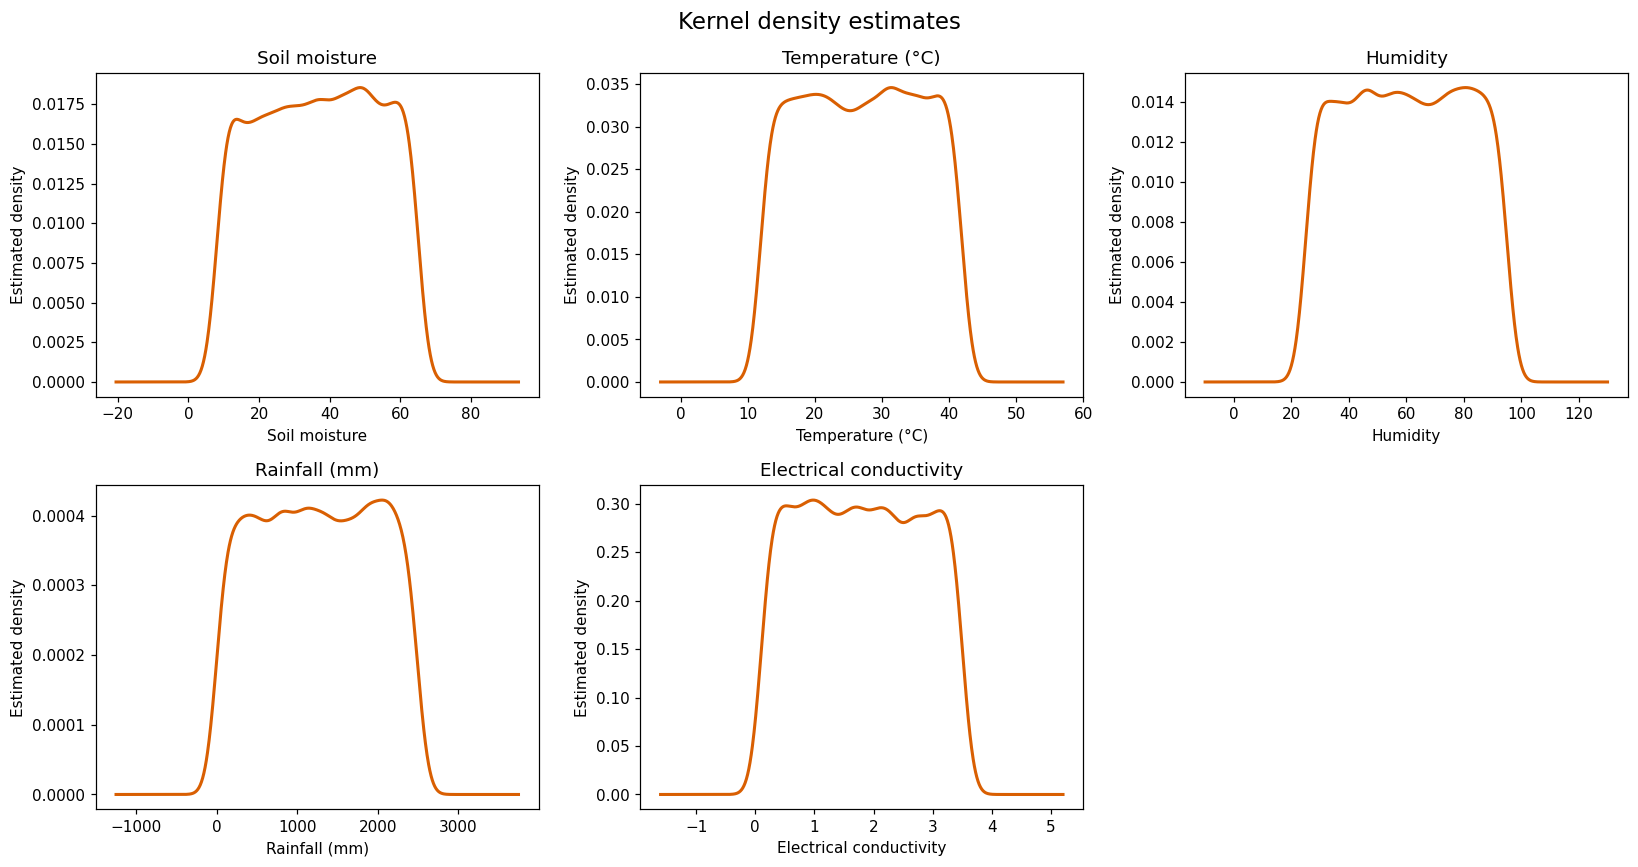

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (column, label) in zip(axes.flat, selected.items()):
    measurements[column].dropna().plot.kde(ax=ax, color='#d95f02', lw=2)
    ax.set(title=label, xlabel=label, ylabel='Estimated density')
for ax in list(axes.flat)[len(selected):]:
    ax.axis('off')
fig.suptitle('Kernel density estimates', fontsize=15)
fig.tight_layout()
plt.show()


## Activity 6 — Calculate skewness

Pandas reports the adjusted Fisher-Pearson sample skewness. Values near zero indicate approximate symmetry; positive and negative values indicate longer right and left tails respectively.


In [6]:
skewness = measurements.skew().rename('Skewness').round(4)
print(skewness.to_string())


Soil_Moisture             -0.0398
Temperature_C             -0.0114
Humidity                  -0.0067
Rainfall_mm               -0.0127
Electrical_Conductivity    0.0195


## Activity 7 — Identify potential outliers

Use Tukey's 1.5 × IQR fences as a screening rule. Flagged readings are **potential** outliers, not automatically measurement errors.


In [7]:
q1 = measurements.quantile(0.25)
q3 = measurements.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outlier_mask = measurements.lt(lower_fence) | measurements.gt(upper_fence)
outliers = pd.DataFrame({
    'Lower_fence': lower_fence,
    'Upper_fence': upper_fence,
    'Potential_outliers': outlier_mask.sum(),
    'Percent_of_valid': 100 * outlier_mask.sum() / measurements.count(),
}).round(3)
print(outliers.to_string())


                         Lower_fence  Upper_fence  Potential_outliers  Percent_of_valid
Soil_Moisture                -19.260       93.060                   0               0.0
Temperature_C                 -3.100       57.060                   0               0.0
Humidity                      -9.420      129.980                   0               0.0
Rainfall_mm                -1235.010     3749.430                   0               0.0
Electrical_Conductivity       -1.625        5.215                   0               0.0


## Activity 8 — Compare with theoretical distributions

Overlay fitted normal and uniform probability densities on each histogram. The Kolmogorov–Smirnov statistic D is used only as a **descriptive distance**: smaller means closer to the fitted curve. Parameters are estimated from these same readings, so the table does not report significance p-values.


                         KS_D_normal  KS_D_uniform Closer_fit
Variable                                                     
Soil_Moisture                 0.0580        0.0165    Uniform
Temperature_C                 0.0598        0.0061    Uniform
Humidity                      0.0602        0.0059    Uniform
Rainfall_mm                   0.0619        0.0084    Uniform
Electrical_Conductivity       0.0617        0.0090    Uniform


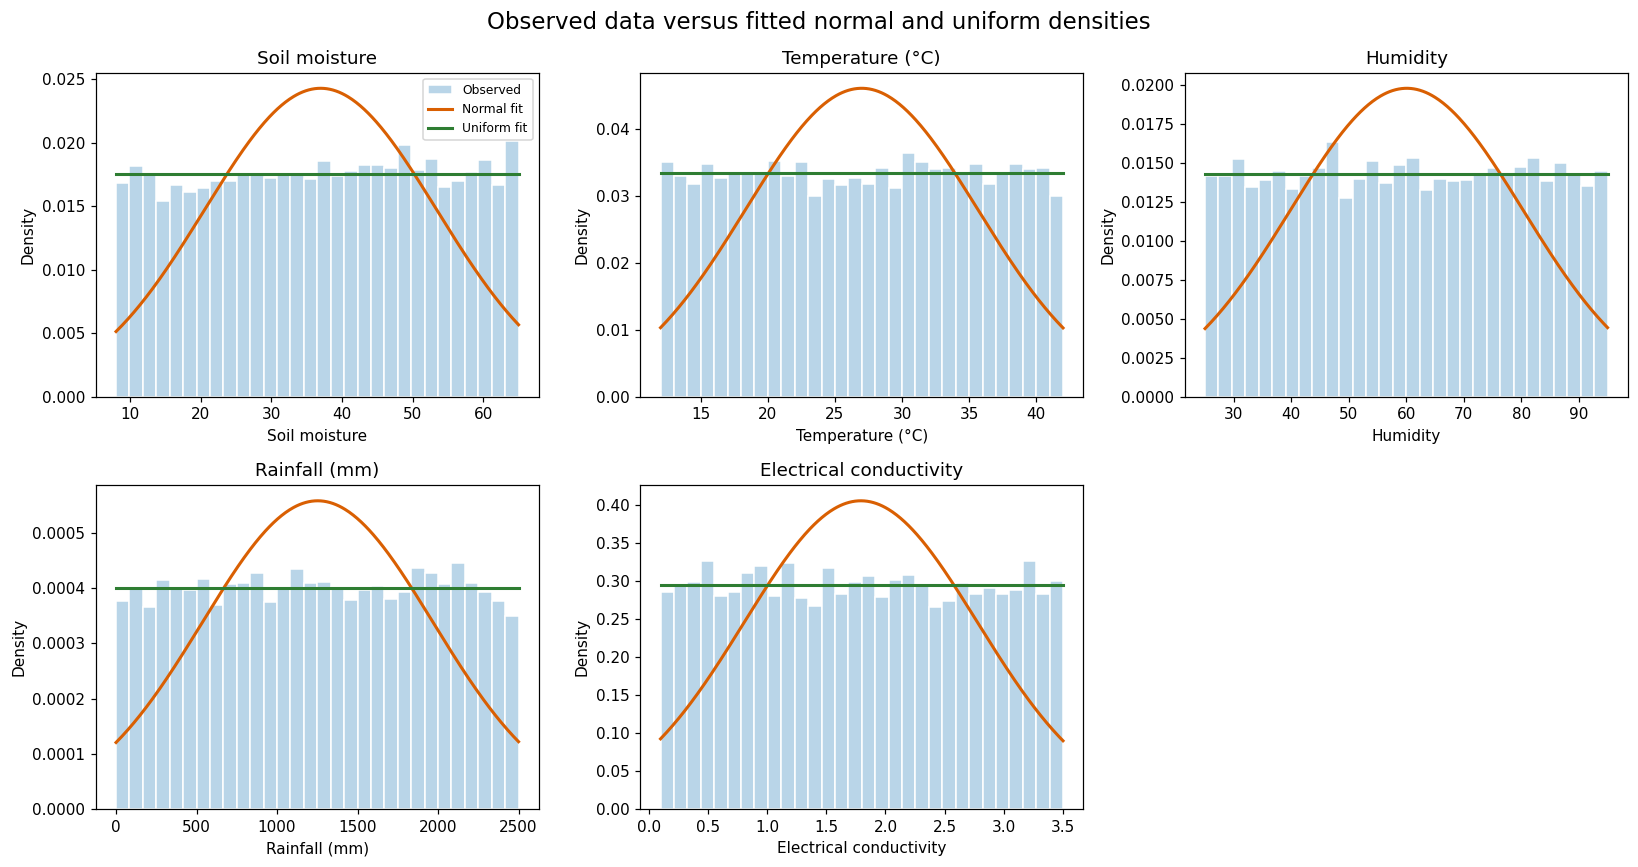

In [8]:
comparison_rows = []
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (column, label) in zip(axes.flat, selected.items()):
    values = measurements[column].dropna().to_numpy()
    mu, sigma = stats.norm.fit(values)
    uniform_loc, uniform_scale = stats.uniform.fit(values)
    grid = np.linspace(values.min(), values.max(), 400)
    ax.hist(values, bins=30, density=True, color='#b9d5e8', edgecolor='white', label='Observed')
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), color='#d95f02', lw=2, label='Normal fit')
    ax.plot(grid, stats.uniform.pdf(grid, uniform_loc, uniform_scale), color='#2e7d32', lw=2, label='Uniform fit')
    ax.set(title=label, xlabel=label, ylabel='Density')
    d_normal = stats.kstest(values, stats.norm.cdf, args=(mu, sigma)).statistic
    d_uniform = stats.kstest(values, stats.uniform.cdf,
                             args=(uniform_loc, uniform_scale)).statistic
    comparison_rows.append((column, d_normal, d_uniform,
                            'Normal' if d_normal < d_uniform else 'Uniform'))
for ax in list(axes.flat)[len(selected):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Observed data versus fitted normal and uniform densities', fontsize=15)
fig.tight_layout()
plt.show()
comparison = pd.DataFrame(comparison_rows, columns=['Variable', 'KS_D_normal',
                                                      'KS_D_uniform', 'Closer_fit']).set_index('Variable')
print(comparison.round(4).to_string())


## Activity 9 — Interpret each selected variable

The text below is derived from the measured skewness, IQR screen, and descriptive fit comparison.


In [9]:
for column, label in selected.items():
    value = skewness[column]
    shape = ('approximately symmetric' if abs(value) < 0.2 else
             'right-skewed' if value > 0 else 'left-skewed')
    n_flagged = int(outliers.loc[column, 'Potential_outliers'])
    closer = comparison.loc[column, 'Closer_fit'].lower()
    print(f'{label}: mean={summary.loc[column, "Mean"]:.3f}, '
          f'median={summary.loc[column, "Median"]:.3f}, '
          f'SD={summary.loc[column, "Std_dev_sample"]:.3f}; '
          f'{shape} (skewness={value:.4f}); '
          f'{n_flagged} IQR-screened potential outliers; '
          f'{closer} has the smaller descriptive KS distance.')


Soil moisture: mean=36.969, median=37.240, SD=16.431; approximately symmetric (skewness=-0.0398); 0 IQR-screened potential outliers; uniform has the smaller descriptive KS distance.
Temperature (°C): mean=26.991, median=27.090, SD=8.664; approximately symmetric (skewness=-0.0114); 0 IQR-screened potential outliers; uniform has the smaller descriptive KS distance.
Humidity: mean=60.080, median=60.040, SD=20.188; approximately symmetric (skewness=-0.0067); 0 IQR-screened potential outliers; uniform has the smaller descriptive KS distance.
Rainfall (mm): mean=1252.499, median=1250.335, SD=715.582; approximately symmetric (skewness=-0.0127); 0 IQR-screened potential outliers; uniform has the smaller descriptive KS distance.
Electrical conductivity: mean=1.792, median=1.780, SD=0.984; approximately symmetric (skewness=0.0195); 0 IQR-screened potential outliers; uniform has the smaller descriptive KS distance.


## Activity 10 — Discuss effects on robotic or irrigation data analysis

- The histograms and density curves show the range and shape of each measurement. The observed readings are approximately symmetric and, within the two fitted candidates, closer to a uniform distribution. A normal-only threshold or simulator would therefore misrepresent the observed shape.
- Means and standard deviations use the variable's own units. A model combining soil moisture, temperature, rainfall, and conductivity should scale these features appropriately so rainfall's larger numeric range does not dominate a distance-based method.
- The IQR rule is a first screen for unusual readings. A future sensor system should check flagged values against physical limits, calibration, time stamps, and local conditions before rejecting them.
- This dataset is a static irrigation table. It does not provide sensor time series, sensor uncertainty, or fault labels, so these plots alone cannot establish temporal drift or confirm a sensor fault.

**Conclusion:** The selected irrigation measurements were summarized and visualized, skewness and possible outliers were calculated, and observed shapes were compared descriptively with fitted normal and uniform distributions.
